1. Converted timestamp to datetime format: To enable extraction of temporal information such as hour of day and day of week.
2. Created hour and day_of_week: Mental workload often occurs at specific times, so temporal context may improve prediction performance.
3. Calculated missing counts and percentages: To evaluate data quality and identify sensor reliability issues.
4. Applied linear interpolation to physiological signals: Smartwatch sensors occasionally miss measurements. Interpolation preserves temporal continuity without removing large amounts of data.
5. Removed remaining incomplete records: Ensures machine learning models receive complete observations and prevents training errors.
6. Checked for duplicate rows: Duplicate observations can bias model training and evaluation.
7. Identified abnormal heart-rate and respiration-rate values: Sensor errors or unrealistic physiological measurements can negatively affect model performance.
8. Removed respiration values outside plausible physiological ranges: Improves data quality and reduces noise.
9. Examined cognitive vs non-cognitive labels: To identify potential class imbalance which may affect model training and evaluation.
10. Selected physiological and temporal variables: To retain features most relevant to predicting mental workload.
11. Standardized continuous variables using StandardScaler: Prevents features with larger numeric ranges from dominating the learning process. Particularly important for SVM and neural networks.
12. Saved full_df_preprocessed.csv: Creates a clean dataset ready for feature engineering and machine learning experiments.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


In [2]:
# load the dataset
df = pd.read_csv("../final_dfs/full_df.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape:
(4320, 7)

Columns:
['timestamp', 'stress', 'body_battery', 'respiration_rate', 'heart_rate', 'activity_type', 'is_cognitive']


,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive
0,2026-06-03 00:00:00,NaN,NaN,NaN,NaN,NaN,0
1,2026-06-03 00:01:00,12.0,32.0,13.58,NaN,NaN,0
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,NaN,0
3,2026-06-03 00:03:00,NaN,NaN,14.91,74.0,generic,0
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,sedentary,0


In [3]:
# Convert Timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.dtypes)


timestamp           datetime64[us]
stress                     float64
body_battery               float64
respiration_rate           float64
heart_rate                 float64
activity_type                  str
is_cognitive                 int64
dtype: object


In [4]:
# Create Temporal Features
df["hour"] = df["timestamp"].dt.hour

df["day_of_week"] = df["timestamp"].dt.dayofweek

df[["timestamp", "hour", "day_of_week"]].head()

,timestamp,hour,day_of_week
0,2026-06-03 00:00:00,0,2
1,2026-06-03 00:01:00,0,2
2,2026-06-03 00:02:00,0,2
3,2026-06-03 00:03:00,0,2
4,2026-06-03 00:04:00,0,2


                  Missing Count  Missing Percentage
timestamp                     0                0.00
stress                      545               12.62
body_battery                213                4.93
respiration_rate            858               19.86
heart_rate                  805               18.63
activity_type               182                4.21
is_cognitive                  0                0.00
hour                          0                0.00
day_of_week                   0                0.00


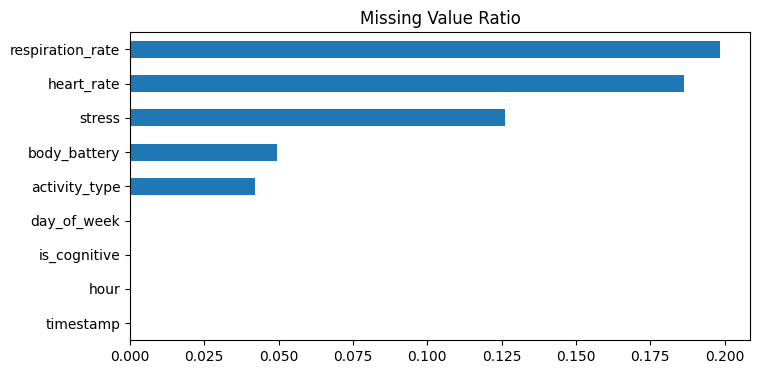

In [5]:
# Missing value analysis

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

print(missing_summary)

plt.figure(figsize=(8,4))

(df.isna().mean().sort_values()).plot(kind="barh")

plt.title("Missing Value Ratio")
plt.show()

In [6]:
sensor_cols = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate"
]

df[sensor_cols] = df[sensor_cols].interpolate(
    method="linear",
    limit_direction="both"
)

In [7]:
print(df.isna().sum())

timestamp             0
stress                0
body_battery          0
respiration_rate      0
heart_rate            0
activity_type       182
is_cognitive          0
hour                  0
day_of_week           0
dtype: int64


In [8]:
# Remove Remaining Missing Values
before_rows = len(df)

df = df.dropna()

after_rows = len(df)

print("Rows Before:", before_rows)
print("Rows After :", after_rows)
print("Rows Removed:", before_rows - after_rows)

Rows Before: 4320
Rows After : 4138
Rows Removed: 182


In [9]:
# Duplicate Check
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# df = df.drop_duplicates()

Duplicate Rows: 0


In [10]:
# Outlier Detection
hr_outliers = df[
    (df["heart_rate"] < 30) |
    (df["heart_rate"] > 220)
]

print("Heart Rate Outliers:", len(hr_outliers))

resp_outliers = df[
    (df["respiration_rate"] < 5) |
    (df["respiration_rate"] > 40)
]

print("Respiration Outliers:", len(resp_outliers))

Heart Rate Outliers: 0
Respiration Outliers: 24


In [11]:
# Remove Outliers
df = df[
    (df["heart_rate"] >= 30) &
    (df["heart_rate"] <= 220)
]

df = df[
    (df["respiration_rate"] >= 5) &
    (df["respiration_rate"] <= 40)
]

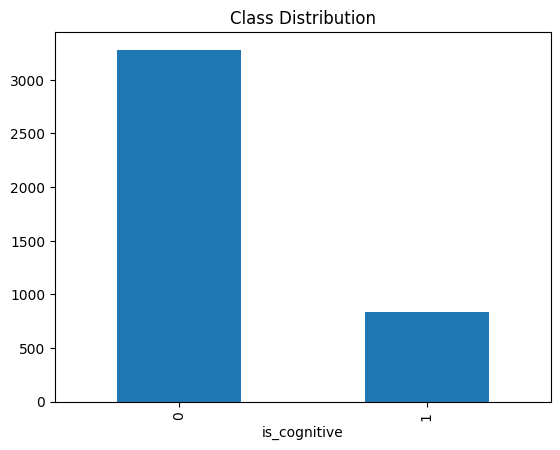

In [12]:
# Target Variable Check
df["is_cognitive"].value_counts()
df["is_cognitive"].value_counts(normalize=True)

df["is_cognitive"].value_counts().plot(kind="bar")

plt.title("Class Distribution")

plt.show()

In [13]:
# Feature Selection
features = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate",
    "hour",
    "day_of_week"
]

target = "is_cognitive"

In [14]:
# Feature Scaling
# day_of_week is categorical.
# Monday is not "halfway" between Sunday and Tuesday.

scaler = StandardScaler()

features_to_scale = [
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate",
    "hour"
]

df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

df[features_to_scale].describe()

,stress,body_battery,respiration_rate,heart_rate,hour
count,4.114000e+03,4.114000e+03,4.114000e+03,4.114000e+03,4.114000e+03
mean,-9.671948e-17,-1.519878e-16,-1.139908e-16,2.348902e-16,-2.763414e-17
std,1.000122e+00,1.000122e+00,1.000122e+00,1.000122e+00,1.000122e+00
min,-1.071233e+00,-1.720813e+00,-3.603311e+00,-1.537618e+00,-1.694945e+00
25%,-7.384559e-01,-8.756040e-01,-6.520656e-01,-8.027887e-01,-7.930110e-01
50%,-2.808870e-01,-7.735082e-02,2.430122e-02,-1.904314e-01,-4.139895e-02
75%,5.094591e-01,8.617705e-01,6.522381e-01,5.535828e-01,8.605355e-01
max,3.130081e+00,1.847848e+00,3.399331e+00,5.137078e+00,1.762470e+00


In [15]:
# Final Dataset
print(df.shape)

df.head()

(4114, 9)


,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive,hour,day_of_week
3,2026-06-03 00:03:00,-0.114498,-1.204296,0.276884,0.176983,generic,0,-1.694945,2
4,2026-06-03 00:04:00,-0.072901,-1.204296,1.004148,-0.435374,sedentary,0,-1.694945,2
5,2026-06-03 00:05:00,0.634251,-1.204296,0.714549,-0.129196,sedentary,0,-1.694945,2
6,2026-06-03 00:06:00,0.155883,-1.204296,0.424950,-0.435374,sedentary,0,-1.694945,2
7,2026-06-03 00:07:00,-0.322484,-1.204296,-0.228282,-0.680317,sedentary,0,-1.694945,2


In [16]:
print(
    df["is_cognitive"]
    .value_counts(normalize=True)
)

is_cognitive
0    0.797521
1    0.202479
Name: proportion, dtype: float64


In [17]:
print(df.isna().sum())

timestamp           0
stress              0
body_battery        0
respiration_rate    0
heart_rate          0
activity_type       0
is_cognitive        0
hour                0
day_of_week         0
dtype: int64


In [18]:
test=df.to_csv(
    "../final_dfs/full_df_preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.


In [19]:
test = pd.read_csv("../final_dfs/full_df_preprocessed.csv")

print(test.shape)

test.head()

(4114, 9)


,timestamp,stress,body_battery,respiration_rate,heart_rate,activity_type,is_cognitive,hour,day_of_week
0,2026-06-03 00:03:00,-0.114498,-1.204296,0.276884,0.176983,generic,0,-1.694945,2
1,2026-06-03 00:04:00,-0.072901,-1.204296,1.004148,-0.435374,sedentary,0,-1.694945,2
2,2026-06-03 00:05:00,0.634251,-1.204296,0.714549,-0.129196,sedentary,0,-1.694945,2
3,2026-06-03 00:06:00,0.155883,-1.204296,0.424950,-0.435374,sedentary,0,-1.694945,2
4,2026-06-03 00:07:00,-0.322484,-1.204296,-0.228282,-0.680317,sedentary,0,-1.694945,2
